# Spornado Disease Risk Model
## Exploratory Data Analysis

Comprehensive characterisation of the GPS-enriched trap dataset. Every finding in this notebook directly informs a design decision in the three-component scoring architecture.

| Triangle Component | Data Source | Output |
|---|---|---|
| **Weather** | Open-source API, matched by GPS coordinates | Risk score 0–10 via ML model |
| **Hybrid** | Seed catalog disease tolerance ratings | Risk score 0–10 via lookup table |
| **Spornado** | Trap cassette spore count | Risk score 0–10 via percentile normalisation |

**Training scope:** `More Data.csv` — GPS-enabled records with verified weather enrichment. Every row entering model training has a confirmed location, matched weather station, and measured spore count. Records without GPS coordinates are excluded from model training; they cannot satisfy the weather component of the triangle.

In [21]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path("..").resolve()))
from src.config_loader import load as load_config

warnings.filterwarnings("ignore")

# ── Aesthetics ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi":        120,
    "figure.facecolor":  "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         10,
})

# ── Config — single source of truth ─────────────────────────────────────────
cfg           = load_config()
WEATHER_COLS  = cfg["features"]["weather"]
CROPS         = cfg["crops"]
OUTPUTS       = Path("../outputs")
OUTPUTS.mkdir(parents=True, exist_ok=True)

# ── Load enriched dataset ─────────────────────────────────────────────────────
raw = pd.read_csv(cfg["paths"]["data_merged"], low_memory=False)

# Normalise column names → lowercase, underscores
raw.columns = (
    raw.columns.str.strip()
               .str.lower()
               .str.replace(r"[\s\.\-]+", "_", regex=True)
)

# Parse dates
raw["start_date"] = pd.to_datetime(raw["start_date"], errors="coerce")
raw["end_date"]   = pd.to_datetime(raw["end_date"],   errors="coerce")

# Spore count — strip comma separators, clip negatives
raw["spore_count"] = (
    pd.to_numeric(
        raw["spore_count"].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    ).clip(lower=0)
)

# Binary outcome  (1 = disease detected)
raw["disease_present"] = (
    raw["result"].astype(str).str.strip().str.lower() == "positive"
).astype(int)

# GPS validity (WGS-84 bounds)
raw["lat"] = pd.to_numeric(
    raw.get("gps_latitude", pd.Series(dtype=str)).astype(str).str.lstrip("'"),
    errors="coerce",
)
raw["lon"] = pd.to_numeric(
    raw.get("gps_longitude", pd.Series(dtype=str)).astype(str).str.lstrip("'"),
    errors="coerce",
)
raw["has_gps"]     = raw["lat"].between(-90, 90) & raw["lon"].between(-180, 180)
raw["has_weather"] = raw[[c for c in WEATHER_COLS if c in raw.columns]].notna().all(axis=1)

# Crop type normalisation
raw["crop_type"] = raw["crop_type"].astype(str).str.strip().str.title()

# Temporal features
raw["year"]        = raw["start_date"].dt.year
raw["month"]       = raw["start_date"].dt.month
raw["week"]        = raw["start_date"].dt.isocalendar().week.astype("Int64")
raw["day_of_year"] = raw["start_date"].dt.dayofyear

df = raw.copy()

print(f"{'Rows':<24}: {len(df):,}")
print(f"{'Columns':<24}: {df.shape[1]}")
print(f"{'Date range':<24}: {df['start_date'].min().date()} – {df['start_date'].max().date()}")
print(f"{'GPS-valid rows':<24}: {df['has_gps'].sum():,}  ({df['has_gps'].mean()*100:.1f}%)")
print(f"{'Weather-matched rows':<24}: {df['has_weather'].sum():,}  ({df['has_weather'].mean()*100:.1f}%)")
print(f"{'Target crops in config':<24}: {CROPS}")
print(f"{'Weather features':<24}: {len(WEATHER_COLS)} columns")

Rows                    : 3,784
Columns                 : 35
Date range              : 2025-05-15 – 2026-02-01
GPS-valid rows          : 3,755  (99.2%)
Weather-matched rows    : 3,755  (99.2%)
Target crops in config  : ['Corn', 'Soybean', 'Wheat']
Weather features        : 7 columns


## 1. Dataset Overview

Record counts, crop coverage, and the proportion of triangle-complete rows available for model training.

  Total records               : 3,784
  Crops (config targets)      : Corn, Soybean, Wheat
  Date range                  : 2025-05-15 – 2026-02-01
  GPS-valid rows              : 3,755  (99.2%)
  Weather-matched rows        : 3,755  (99.2%)
  Overall positive rate       : 67.3%

           Total records  Weather-matched  Triangle-complete %  Positive rate %
crop_type                                                                      
Corn              2748.0           2748.0                100.0             67.2
Soybean            625.0            625.0                100.0             73.4
Wheat              411.0            382.0                 92.9             58.4


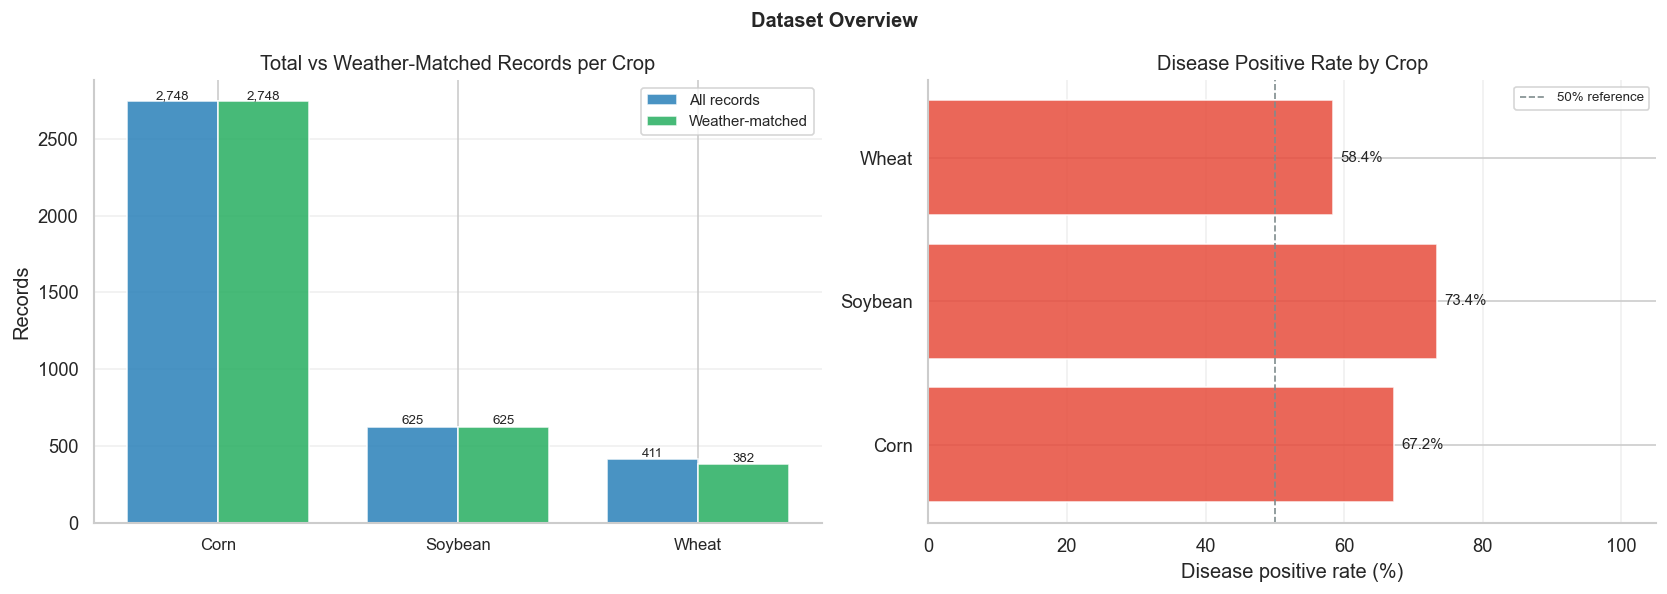

In [22]:
# ── High-level summary ────────────────────────────────────────────────────────
summary = {
    "Total records":          f"{len(df):,}",
    "Crops (config targets)": ", ".join(CROPS),
    "Date range":             f"{df['start_date'].min().date()} – {df['start_date'].max().date()}",
    "GPS-valid rows":         f"{df['has_gps'].sum():,}  ({df['has_gps'].mean()*100:.1f}%)",
    "Weather-matched rows":   f"{df['has_weather'].sum():,}  ({df['has_weather'].mean()*100:.1f}%)",
    "Overall positive rate":  f"{df['disease_present'].mean()*100:.1f}%",
}
for k, v in summary.items():
    print(f"  {k:<28}: {v}")

# ── Per-crop breakdown ────────────────────────────────────────────────────────
df_target = df[df["crop_type"].isin(CROPS)]

crop_stats = (
    df_target.groupby("crop_type")
    .apply(lambda g: pd.Series({
        "Total records":       len(g),
        "Weather-matched":     g["has_weather"].sum(),
        "Triangle-complete %": round(g["has_weather"].mean() * 100, 1),
        "Positive rate %":     round(g["disease_present"].mean() * 100, 1),
    }), include_groups=False)
    .loc[CROPS]
)
print()
print(crop_stats.to_string())

# ── Visual ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dataset Overview", fontsize=12, fontweight="bold")

x = range(len(crop_stats))
w = 0.38
axes[0].bar([i - w/2 for i in x], crop_stats["Total records"],
            width=w, label="All records", color="#2980b9", edgecolor="white", alpha=0.85)
axes[0].bar([i + w/2 for i in x], crop_stats["Weather-matched"],
            width=w, label="Weather-matched", color="#27ae60", edgecolor="white", alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(crop_stats.index, fontsize=10)
axes[0].set_ylabel("Records")
axes[0].set_title("Total vs Weather-Matched Records per Crop")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)
for i, (tot, wx) in enumerate(zip(crop_stats["Total records"], crop_stats["Weather-matched"])):
    axes[0].text(i - w/2, tot + 15, f"{int(tot):,}", ha="center", fontsize=8)
    axes[0].text(i + w/2, int(wx) + 15, f"{int(wx):,}", ha="center", fontsize=8)

axes[1].barh(crop_stats.index, crop_stats["Positive rate %"],
             color="#e74c3c", edgecolor="white", alpha=0.85)
axes[1].axvline(50, color="#7f8c8d", linewidth=1, linestyle="--", label="50% reference")
axes[1].set_xlabel("Disease positive rate (%)")
axes[1].set_title("Disease Positive Rate by Crop")
axes[1].set_xlim(0, 105)
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", alpha=0.3)
for i, v in enumerate(crop_stats["Positive rate %"]):
    axes[1].text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS / "01_dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()

**Note.** These counts show how much of the merged file is usable for a weather-backed model: configured crops, valid dates, and all weather fields present. The dual bars separate raw row counts from weather-complete rows; the horizontal bars are crude prevalence by crop (positive / negative labels), not model accuracy.

A large gap between “all rows” and weather-matched rows is expected if many traps lack a full weather join. At scoring time we require the same completeness; we do not silently impute missing weather for production inference.

## 2. Data Quality Assessment

Systematic audit across completeness, validity, uniqueness, and consistency. Findings determine which records are eligible for training and flag upstream data issues for remediation.

DATA QUALITY REPORT
  Total records                 : 3,784
  Corrupted dates (year<2010|>2030): 0  → excluded from training
  Missing dates (NaT)           : 0
  Coordinates out of WGS-84 bounds: 0
  Duplicate records             : 2,662

  Missing values in key columns:
    spore_count                       9.5%  ██
    result                            7.4%  █
    lat                               0.8%  █
    temperature_min_c                 0.8%  █
    lon                               0.8%  █
    humidity_max_percent              0.8%  █
    precipitation_mm                  0.8%  █
    temperature_max_c                 0.8%  █
    temperature_mean_c                0.8%  █
    wind_speed_max_kmh                0.8%  █
    dew_point_min_c                   0.8%  █

  Training-eligible rows (weather + valid date + target crop): 3,755


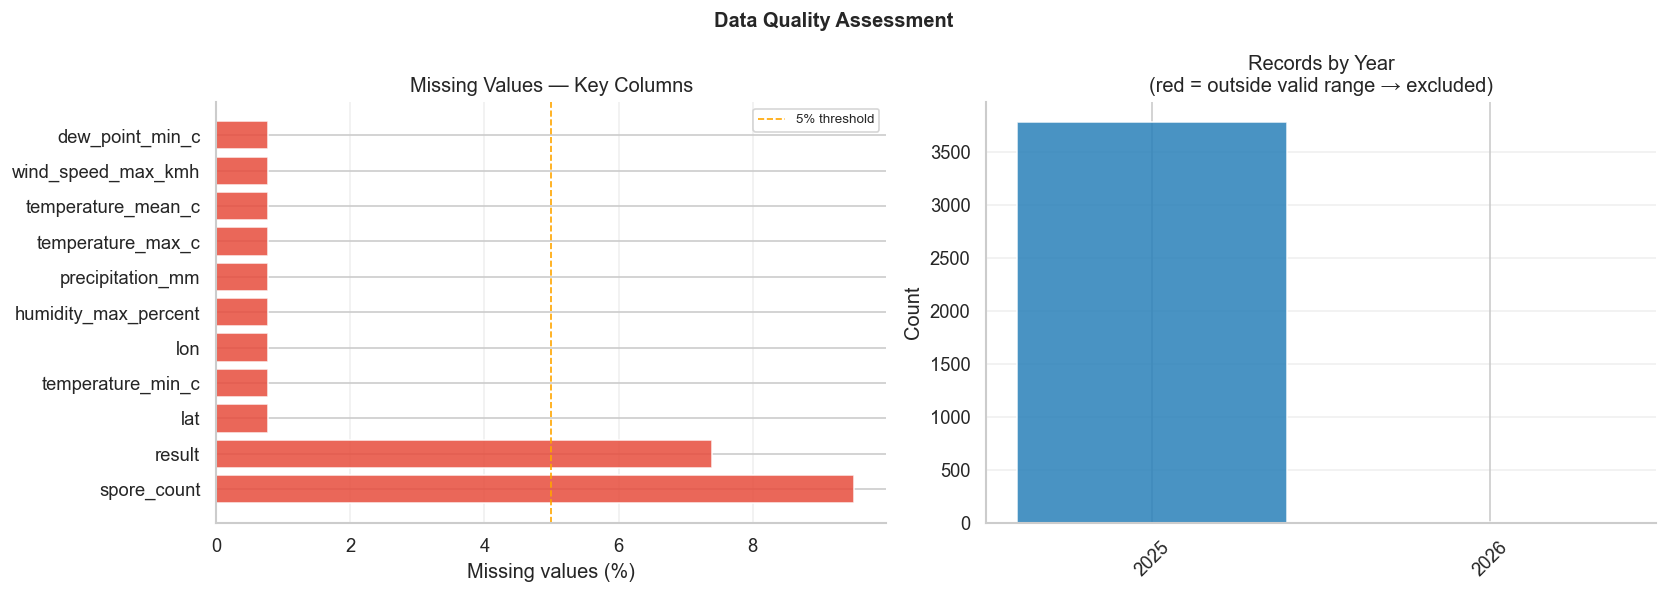

In [23]:
key_cols     = ["crop_type", "result", "start_date", "spore_count", "lat", "lon"] + WEATHER_COLS
present_cols = [c for c in key_cols if c in df.columns]

# ── Completeness ──────────────────────────────────────────────────────────────
miss_pct = (df[present_cols].isna().mean() * 100).sort_values(ascending=False)
miss_pct  = miss_pct[miss_pct > 0]

# ── Date validity ─────────────────────────────────────────────────────────────
valid_years    = df["start_date"].dt.year.between(2010, 2030)
n_corrupt_date = int((~valid_years & df["start_date"].notna()).sum())
n_nat          = int(df["start_date"].isna().sum())

# ── GPS bounds ────────────────────────────────────────────────────────────────
n_coord_invalid = int(
    ((df["lat"] < -90) | (df["lat"] > 90) |
     (df["lon"] < -180) | (df["lon"] > 180)).sum()
)

# ── Duplicates ────────────────────────────────────────────────────────────────
nat_key = [c for c in ["spornado_serial", "cassette", "start_date"] if c in df.columns]
n_dupes = int(df.duplicated(subset=nat_key).sum()) if nat_key else 0

print("DATA QUALITY REPORT")
print("=" * 55)
print(f"  {'Total records':<30}: {len(df):,}")
print(f"  {'Corrupted dates (year<2010|>2030)':<30}: {n_corrupt_date:,}  → excluded from training")
print(f"  {'Missing dates (NaT)':<30}: {n_nat:,}")
print(f"  {'Coordinates out of WGS-84 bounds':<30}: {n_coord_invalid:,}")
print(f"  {'Duplicate records':<30}: {n_dupes:,}")
print()
if len(miss_pct) > 0:
    print("  Missing values in key columns:")
    for col, pct in miss_pct.items():
        bar = "█" * max(1, int(pct / 4))
        print(f"    {col:<30}  {pct:5.1f}%  {bar}")
else:
    print("  No missing values detected in key columns.")

# ── Training-eligible rows after all filters ──────────────────────────────────
df_eligible = df[
    df["has_weather"] &
    df["start_date"].dt.year.between(2010, 2030) &
    df["crop_type"].isin(CROPS)
].copy()
print(f"\n  Training-eligible rows (weather + valid date + target crop): {len(df_eligible):,}")

# ── Visual ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Data Quality Assessment", fontsize=12, fontweight="bold")

if len(miss_pct) > 0:
    axes[0].barh(miss_pct.index, miss_pct.values,
                 color="#e74c3c", edgecolor="white", alpha=0.85)
    axes[0].axvline(5, color="orange", linestyle="--", linewidth=1, label="5% threshold")
    axes[0].set_xlabel("Missing values (%)")
    axes[0].legend(fontsize=8)
    axes[0].grid(axis="x", alpha=0.3)
else:
    axes[0].text(0.5, 0.5, "No missing values\nin key columns",
                 ha="center", va="center", transform=axes[0].transAxes,
                 fontsize=13, color="#27ae60", fontweight="bold")
axes[0].set_title("Missing Values — Key Columns")

year_dist = df["start_date"].dt.year.value_counts().sort_index().dropna()
colors    = ["#e74c3c" if (y < 2010 or y > 2030) else "#2980b9" for y in year_dist.index]
axes[1].bar(year_dist.index.astype(int).astype(str), year_dist.values,
            color=colors, edgecolor="white", alpha=0.85)
axes[1].set_title("Records by Year\n(red = outside valid range → excluded)")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / "02_data_quality.png", dpi=150, bbox_inches="tight")
plt.show()

# Expose for downstream cells
df_train = df_eligible.copy()

**Note.** Missingness and bad years are filtered here before any modeling. Red years on the histogram fall outside the configured year window and are dropped. The “training-eligible” total is the cohort that actually feeds later cells: target crops, valid `start_date`, and full weather columns.

This section explains shrinkage from raw CSV rows to `df_train`; it is data QA, not a score on the classifier.

## 3. Target Variable Analysis

Distribution and class balance of `disease_present` across training-eligible rows. Class imbalance ratio per crop sets `scale_pos_weight` for XGBoost and determines threshold calibration strategy.

TARGET VARIABLE — disease_present  (training-eligible rows)
  Training rows               : 3,755
  Positive (disease = 1)      : 2,531  (67.4%)
  Negative (disease = 0)      : 1,224  (32.6%)
  Imbalance ratio (neg:pos)   : 1 : 0.48

           n_total  n_positive  n_negative  positive_rate_%  scale_pos_weight
crop_type                                                                    
Corn          2748        1847         901             67.2              0.49
Soybean        625         459         166             73.4              0.36
Wheat          382         225         157             58.9              0.70


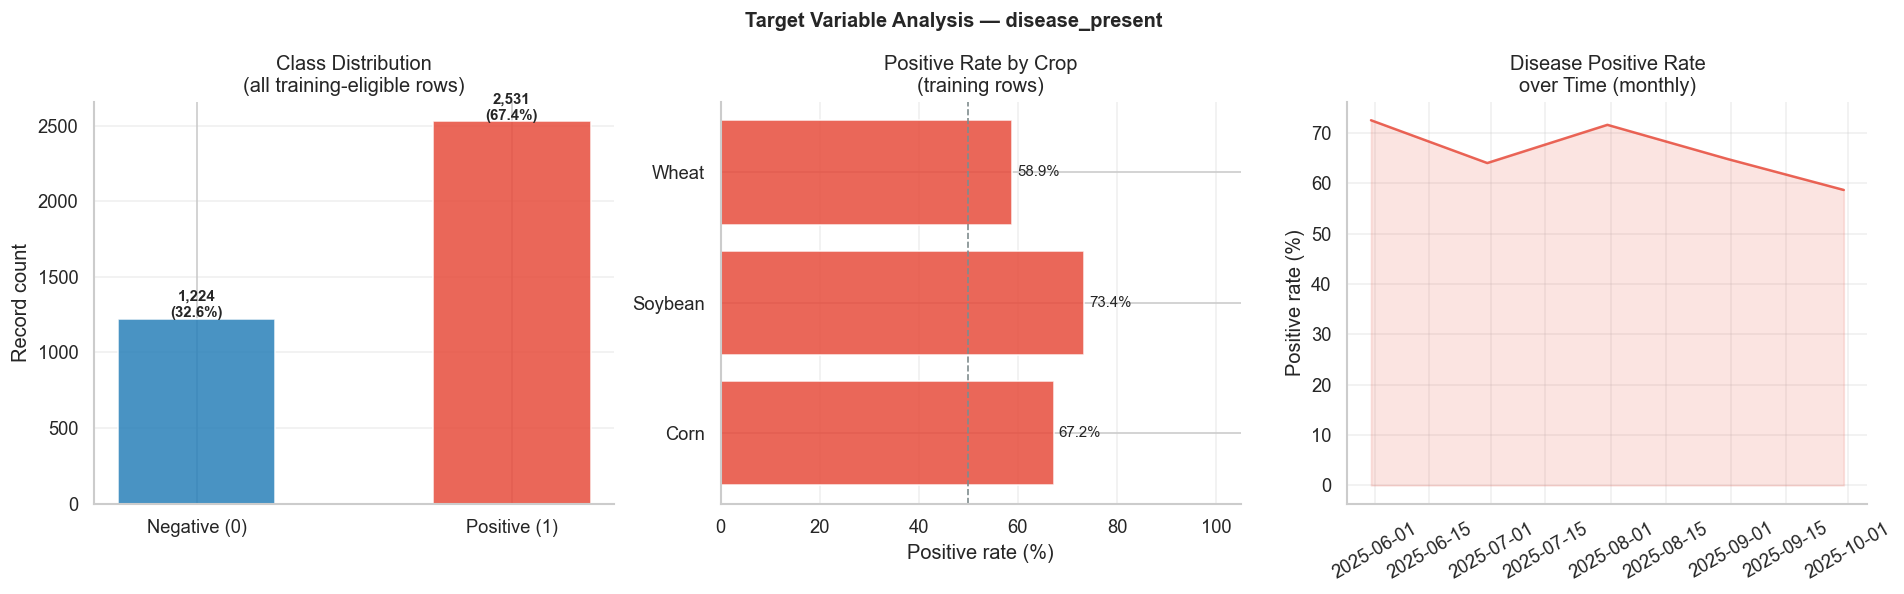

In [24]:
class_counts = df_train["disease_present"].value_counts().sort_index()
overall_pos  = df_train["disease_present"].mean() * 100

print("TARGET VARIABLE — disease_present  (training-eligible rows)")
print("=" * 55)
print(f"  {'Training rows':<28}: {len(df_train):,}")
print(f"  {'Positive (disease = 1)':<28}: {class_counts.get(1, 0):,}  ({overall_pos:.1f}%)")
print(f"  {'Negative (disease = 0)':<28}: {class_counts.get(0, 0):,}  ({100-overall_pos:.1f}%)")
print(f"  {'Imbalance ratio (neg:pos)':<28}: 1 : {class_counts.get(0,1) / max(class_counts.get(1,1), 1):.2f}")
print()

# Per-crop class balance → feeds directly into XGBoost scale_pos_weight
per_crop = (
    df_train.groupby("crop_type")["disease_present"]
    .agg(n_total="count", n_positive="sum")
)
per_crop["n_negative"]       = per_crop["n_total"] - per_crop["n_positive"]
per_crop["positive_rate_%"]  = (per_crop["n_positive"] / per_crop["n_total"] * 100).round(1)
per_crop["scale_pos_weight"] = (per_crop["n_negative"] / per_crop["n_positive"].clip(lower=1)).round(2)
print(per_crop.loc[CROPS].to_string())

# ── Visual ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Target Variable Analysis — disease_present", fontsize=12, fontweight="bold")

# Overall class distribution
axes[0].bar(["Negative (0)", "Positive (1)"],
            [class_counts.get(0, 0), class_counts.get(1, 0)],
            color=["#2980b9", "#e74c3c"], edgecolor="white", alpha=0.85, width=0.5)
axes[0].set_ylabel("Record count")
axes[0].set_title("Class Distribution\n(all training-eligible rows)")
axes[0].grid(axis="y", alpha=0.3)
for i, (lbl, v) in enumerate(zip(["Negative", "Positive"],
                                   [class_counts.get(0, 0), class_counts.get(1, 0)])):
    axes[0].text(i, v + 10, f"{v:,}\n({v/len(df_train)*100:.1f}%)",
                 ha="center", fontsize=9, fontweight="bold")

# Positive rate by crop
pos_rates = per_crop.loc[CROPS, "positive_rate_%"]
axes[1].barh(pos_rates.index, pos_rates.values,
             color="#e74c3c", edgecolor="white", alpha=0.85)
axes[1].axvline(50, color="#7f8c8d", linewidth=1, linestyle="--")
axes[1].set_xlabel("Positive rate (%)")
axes[1].set_title("Positive Rate by Crop\n(training rows)")
axes[1].set_xlim(0, 105)
axes[1].grid(axis="x", alpha=0.3)
for i, v in enumerate(pos_rates.values):
    axes[1].text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)

# Positive rate over time (monthly, all target crops)
monthly = (
    df_train.resample("ME", on="start_date")["disease_present"]
    .mean() * 100
)
axes[2].plot(monthly.index, monthly.values, color="#e74c3c", linewidth=1.5, alpha=0.85)
axes[2].fill_between(monthly.index, monthly.values, alpha=0.15, color="#e74c3c")
axes[2].set_ylabel("Positive rate (%)")
axes[2].set_title("Disease Positive Rate\nover Time (monthly)")
axes[2].tick_params(axis="x", rotation=30)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / "03_target_variable.png", dpi=150, bbox_inches="tight")
plt.show()

**Note.** The label is `disease_present` on eligible rows only. The neg:pos ratio feeds imbalance handling in training (e.g. `scale_pos_weight` for XGBoost). Rates differ by crop, so do not assume one global class balance.

The rolling monthly line is descriptive: it can show seasonality or drift in label frequency over time. High overall positivity does not make the task easy; it pushes you toward proper calibration and an operating threshold chosen on a PR curve, not at 0.5.

## 4. Spore Count Distribution — Spornado Score Foundation

Raw spore counts are the direct input to the Spornado component score (0–10). This section establishes the empirical distribution across all crops, derives the percentile-based normalisation anchors, and validates that the positive-class threshold is defensible.

SPORE COUNT PERCENTILE ANCHORS — Spornado Score Normalisation
 Percentile  Spore count  Spornado score (0-10)
         10         0.00                    1.0
         25         0.00                    2.5
         50       376.00                    5.0
         75      6112.75                    7.5
         90     32962.10                    9.0
         95     88748.65                    9.5
         99    507700.00                    9.9
        100  13848300.00                   10.0

  Total records with spore count  : 3,424
  Zero-count records (no spores)  : 938  (27.4%)
  Non-zero records                : 2,486
  Max recorded spore count        : 13,848,300

Per-crop spore count summary (training crops):
              n  zeros_%  median      p75       p90     maximum
crop_type                                                      
Corn       2456     26.1   334.0   4513.5   22720.5   1660623.0
Soybean     577     20.6  6150.0  34799.0  159133.0  13848300.0
Wheat       391     4

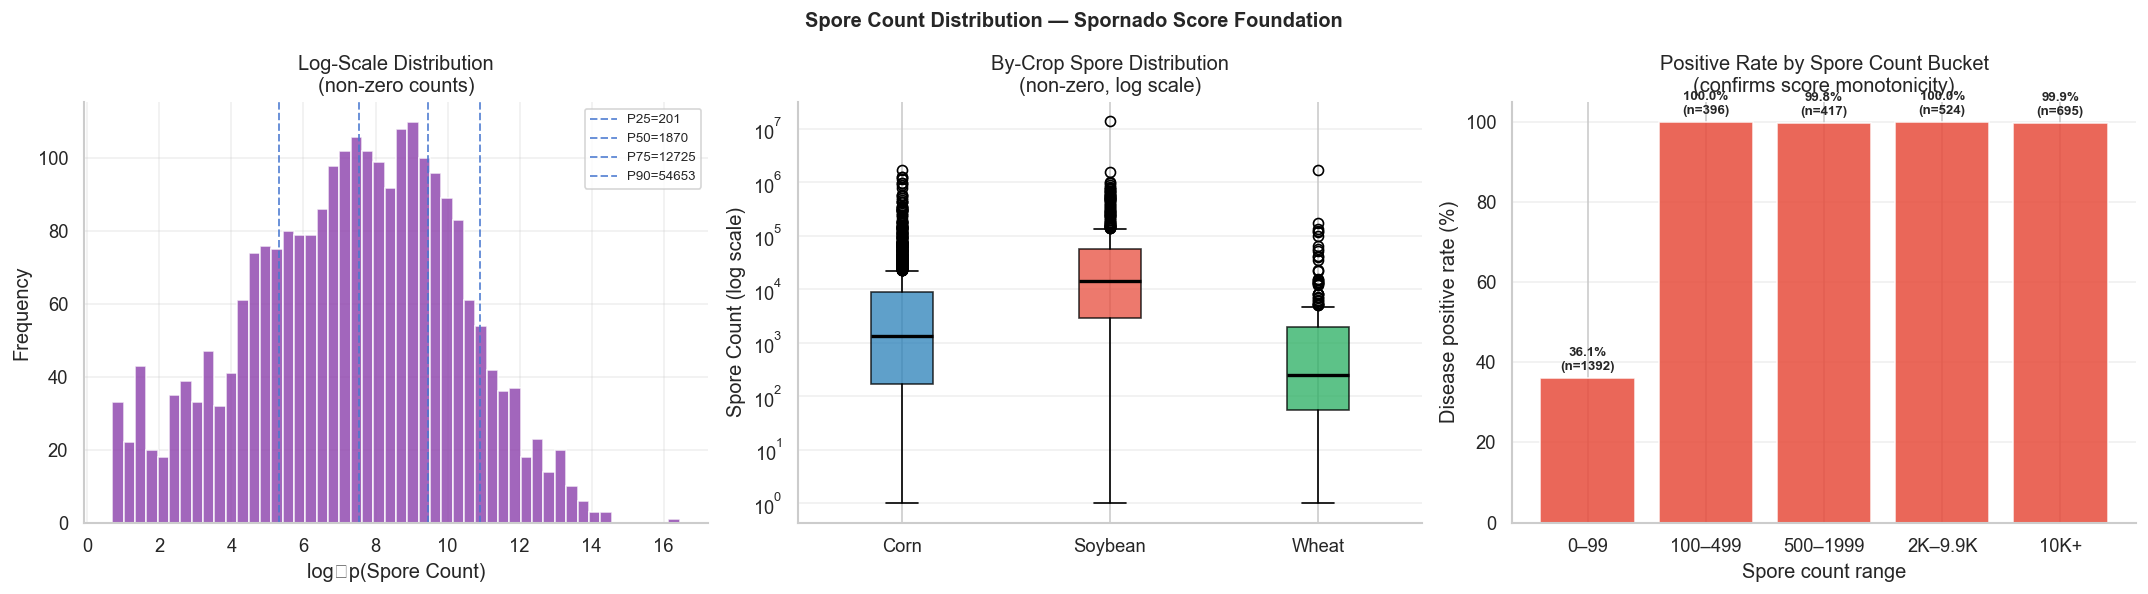

In [25]:
# ── Percentile anchors — Spornado score normalisation ────────────────────────
# Use all records (GPS + non-GPS); spore count does not require GPS.
sc = df["spore_count"].dropna()
sc_pos = sc[sc > 0]

pcts = [10, 25, 50, 75, 90, 95, 99, 100]
anchors = pd.DataFrame({
    "Percentile": pcts,
    "Spore count": [np.percentile(sc, p) for p in pcts],
    "Spornado score (0-10)": [round(p / 10, 1) for p in pcts],
})
print("SPORE COUNT PERCENTILE ANCHORS — Spornado Score Normalisation")
print("=" * 60)
print(anchors.to_string(index=False))
print()
print(f"  Total records with spore count  : {len(sc):,}")
print(f"  Zero-count records (no spores)  : {(sc == 0).sum():,}  ({(sc==0).mean()*100:.1f}%)")
print(f"  Non-zero records                : {len(sc_pos):,}")
print(f"  Max recorded spore count        : {sc.max():,.0f}")
print()

# Per-crop median and IQR
crop_sc = (
    df[df["crop_type"].isin(CROPS)]
    .groupby("crop_type")["spore_count"]
    .agg(
        n="count",
        zeros=lambda x: (x == 0).sum(),
        median="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        maximum="max",
    )
    .loc[CROPS]
)
crop_sc["zeros_%"] = (crop_sc["zeros"] / crop_sc["n"] * 100).round(1)
print("Per-crop spore count summary (training crops):")
print(crop_sc[["n", "zeros_%", "median", "p75", "p90", "maximum"]].to_string())

# ── Visual ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Spore Count Distribution — Spornado Score Foundation", fontsize=12, fontweight="bold")

# Log-scale histogram (non-zero)
axes[0].hist(np.log1p(sc_pos), bins=50, color="#8e44ad", edgecolor="white", alpha=0.82)
axes[0].set_xlabel("log₁p(Spore Count)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Log-Scale Distribution\n(non-zero counts)")
axes[0].grid(alpha=0.3)
for p, lbl in zip([25, 50, 75, 90], ["P25", "P50", "P75", "P90"]):
    v = np.log1p(np.percentile(sc_pos, p))
    axes[0].axvline(v, linestyle="--", linewidth=1.2, alpha=0.8,
                    label=f"{lbl}={np.percentile(sc_pos, p):.0f}")
axes[0].legend(fontsize=8)

# Box-plot by crop (log scale)
df_bp = df[df["crop_type"].isin(CROPS) & (df["spore_count"] > 0)].copy()
crop_order = CROPS
bp_data = [df_bp.loc[df_bp["crop_type"] == c, "spore_count"].dropna().values for c in crop_order]
bp = axes[1].boxplot(bp_data, labels=crop_order, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
colors_bp = ["#2980b9", "#e74c3c", "#27ae60"]
for patch, color in zip(bp["boxes"], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_yscale("log")
axes[1].set_ylabel("Spore Count (log scale)")
axes[1].set_title("By-Crop Spore Distribution\n(non-zero, log scale)")
axes[1].grid(axis="y", alpha=0.3)

# Positive rate vs spore count percentile bucket
edges  = [0, 100, 500, 2000, 10000, sc.max() + 1]
labels = ["0–99", "100–499", "500–1999", "2K–9.9K", "10K+"]
df_tmp = df.copy()
df_tmp["sc_bucket"] = pd.cut(df_tmp["spore_count"], bins=edges, labels=labels, right=False)
pos_by_bucket = (
    df_tmp.groupby("sc_bucket", observed=True)["disease_present"]
    .agg(pos_rate="mean", count="count")
    .reset_index()
)
pos_by_bucket["pos_rate"] *= 100
axes[2].bar(pos_by_bucket["sc_bucket"].astype(str),
            pos_by_bucket["pos_rate"],
            color="#e74c3c", edgecolor="white", alpha=0.85)
axes[2].set_xlabel("Spore count range")
axes[2].set_ylabel("Disease positive rate (%)")
axes[2].set_title("Positive Rate by Spore Count Bucket\n(confirms score monotonicity)")
axes[2].set_ylim(0, 105)
axes[2].grid(axis="y", alpha=0.3)
for i, (rate, cnt) in enumerate(zip(pos_by_bucket["pos_rate"], pos_by_bucket["count"])):
    axes[2].text(i, rate + 2, f"{rate:.1f}%\n(n={int(cnt)})",
                 ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUTS / "04_spore_count.png", dpi=150, bbox_inches="tight")
plt.show()

**Note.** Spore counts are highly skewed; log-scale plots and percentiles are the right way to read them. Per-crop summaries show that concentration differs by crop even before any model.

The buckets relate count bands to label rate as a sanity check (monotonic-ish is good). In the risk model we deliberately avoid using spore count as an input when it would duplicate the label construction, it would be label leakage (or so close to it that the model stops being useful for real deployment); this plot is for understanding the device signal, not for training leakage.

## 4b. Disease Breakdown — Why Disease Identity Is the #1 Model Feature

Each trap cassette tests for a **specific disease**. The same weather conditions produce very different outcomes depending on which disease is being tested — Tar Spot thrives in cool, humid nights (24% positive rate) while Southern Rust explodes in hot, dry wind (95% positive rate).

Without disease identity as a feature the model sees contradictory labels for identical weather, producing a near-random AUC (~0.54). Adding disease as a one-hot feature raised AUC to **0.81–0.92** across all crops.

This section documents the per-disease signal that justifies that design decision.

DISEASE BREAKDOWN — per-disease record counts and positive rates

  Corn
  Disease                                  Rows  Positive    Rate  Feature column
  --------------------------------------  -----  --------  ------  -----------------------------------
  Southern Rust                             552       490   88.8%  disease_southern_rust
  Northern Corn Leaf Blight                 688       574   83.4%  disease_northern_corn_leaf_blight
  Gibberella Ear Rot                        126       101   80.2%  disease_gibberella_ear_rot
  Gray Leaf Spot                            685       531   77.5%  disease_gray_leaf_spot
  Tar Spot                                  682       151   22.1%  disease_tar_spot

  Soybean
  Disease                                  Rows  Positive    Rate  Feature column
  --------------------------------------  -----  --------  ------  -----------------------------------
  Frogeye Leaf Spot                         302       284   94.0%  disease_frogeye_leaf_

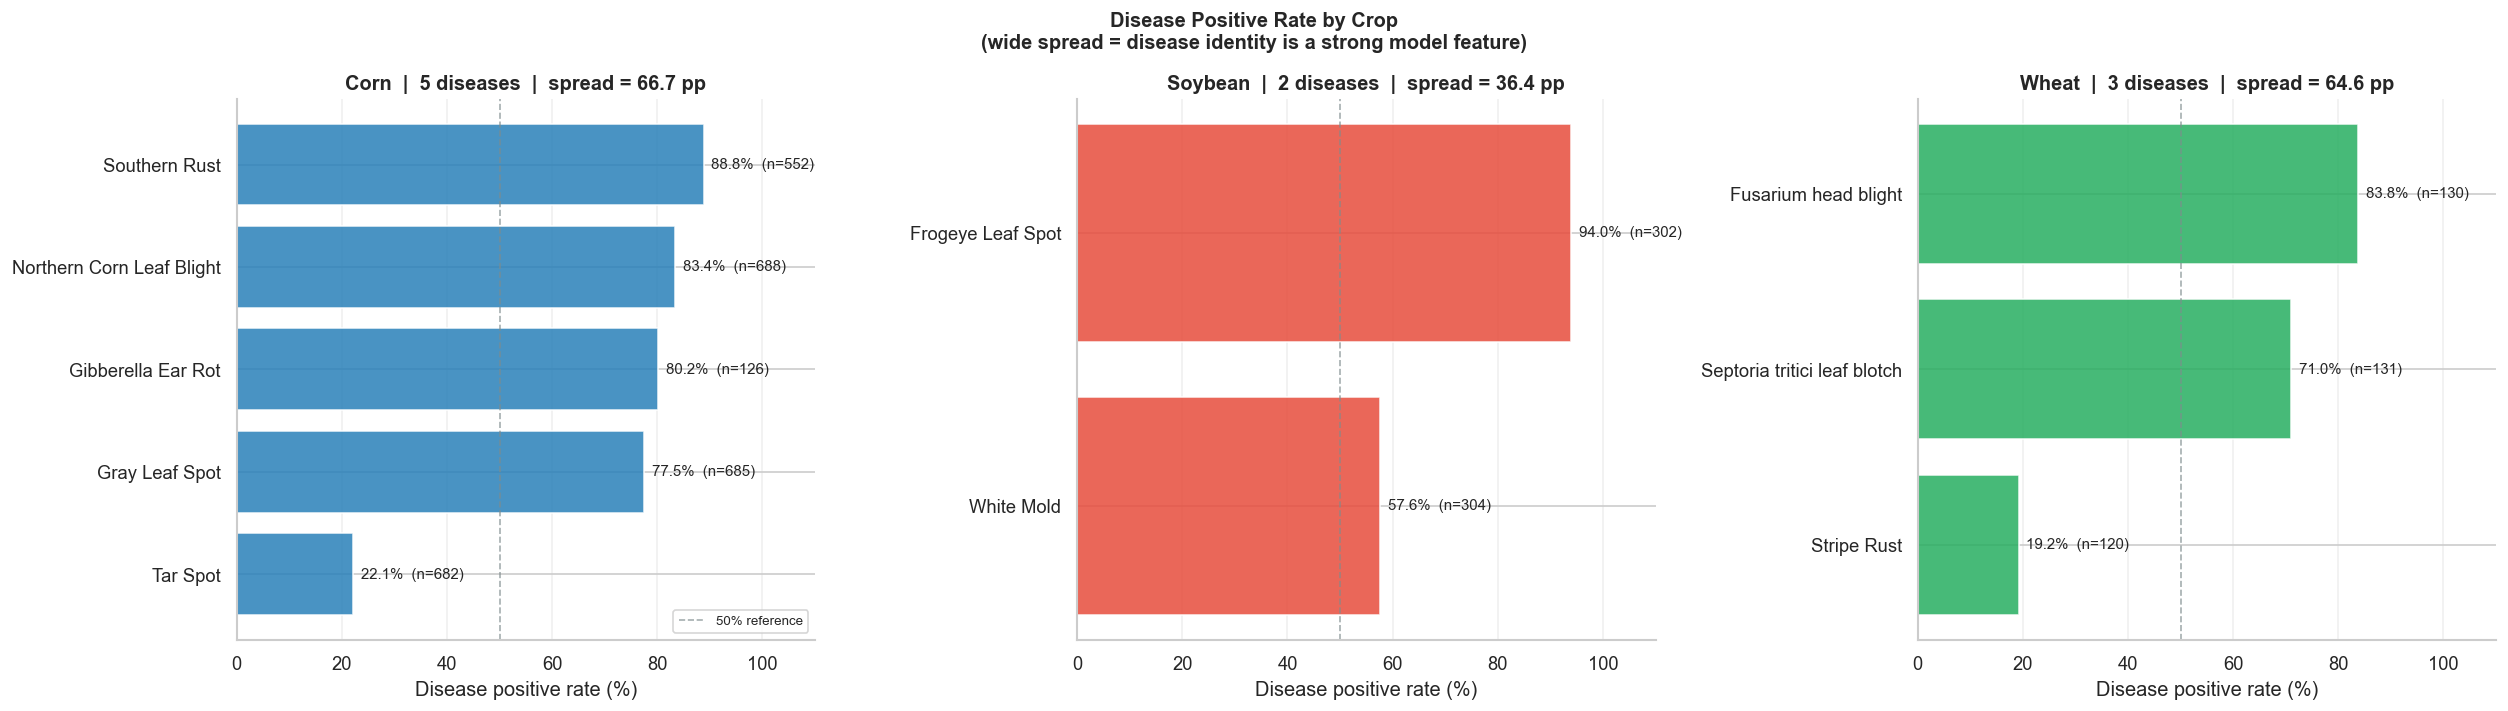

In [41]:
# ── Per-disease positive rate table ───────────────────────────────────────────
test_col = "test"

disease_stats = (
    df_train[df_train["crop_type"].isin(CROPS)]
    .groupby(["crop_type", test_col])
    .agg(
        total_rows      = ("disease_present", "count"),
        positive_rows   = ("disease_present", "sum"),
    )
    .reset_index()
)
disease_stats["negative_rows"]  = disease_stats["total_rows"] - disease_stats["positive_rows"]
disease_stats["positive_rate"]  = (disease_stats["positive_rows"] / disease_stats["total_rows"] * 100).round(1)
disease_stats["disease_dummy"]  = (
    "disease_" + disease_stats[test_col]
    .str.strip().str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

print("DISEASE BREAKDOWN — per-disease record counts and positive rates")
print("=" * 72)
for crop in CROPS:
    sub = disease_stats[disease_stats["crop_type"] == crop].sort_values("positive_rate", ascending=False)
    print(f"\n  {crop}")
    print(f"  {'Disease':<38}  {'Rows':>5}  {'Positive':>8}  {'Rate':>6}  Feature column")
    print(f"  {'-'*38}  {'-'*5}  {'-'*8}  {'-'*6}  {'-'*35}")
    for _, r in sub.iterrows():
        print(
            f"  {r[test_col]:<38}  {int(r['total_rows']):>5}  "
            f"{int(r['positive_rows']):>8}  {r['positive_rate']:>5.1f}%  {r['disease_dummy']}"
        )

# ── Visual — grouped bar chart per crop ───────────────────────────────────────
n_crops  = len(CROPS)
palette  = {"Corn": "#2980b9", "Soybean": "#e74c3c", "Wheat": "#27ae60"}

fig, axes = plt.subplots(1, n_crops, figsize=(7 * n_crops, 6), sharey=False)
fig.suptitle(
    "Disease Positive Rate by Crop\n"
    "(wide spread = disease identity is a strong model feature)",
    fontsize=12, fontweight="bold",
)

if n_crops == 1:
    axes = [axes]

for ax, crop in zip(axes, CROPS):
    sub = (
        disease_stats[disease_stats["crop_type"] == crop]
        .sort_values("positive_rate", ascending=True)
    )
    bars = ax.barh(
        sub[test_col], sub["positive_rate"],
        color=palette.get(crop, "#7f8c8d"), edgecolor="white", alpha=0.85,
    )
    ax.axvline(50, color="#7f8c8d", linewidth=1, linestyle="--", alpha=0.7, label="50% reference")
    ax.set_xlabel("Disease positive rate (%)")
    ax.set_title(f"{crop}  ({len(sub)} diseases)", fontweight="bold")
    ax.set_xlim(0, 110)
    ax.grid(axis="x", alpha=0.3)

    # Annotate bars with rate + count
    for bar, (_, row) in zip(bars.patches, sub.iterrows()):
        ax.text(
            row["positive_rate"] + 1.5,
            bar.get_y() + bar.get_height() / 2,
            f"{row['positive_rate']:.1f}%  (n={int(row['total_rows'])})",
            va="center", fontsize=9,
        )

    # Highlight the range — bigger spread = more model value
    lo, hi = sub["positive_rate"].min(), sub["positive_rate"].max()
    spread = hi - lo
    ax.set_title(
        f"{crop}  |  {len(sub)} diseases  |  spread = {spread:.1f} pp",
        fontweight="bold",
    )

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUTS / "04b_disease_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

**Note.** Within one crop, different `test` (disease) names can have very different positive rates. That is why the production models carry disease as a categorical feature: the same weather profile does not mean the same risk pathogen-by-pathogen.

## 5. Temporal Dynamics

Seasonal deployment patterns, year-over-year volume trends, and monthly disease incidence. These patterns inform the temporal features (`month`, `day_of_year`, `week_of_year`) and the chronological train/test split boundary.

TEMPORAL DYNAMICS — Training-Eligible Rows
  Date range          : 2025-05-15 – 2025-09-25
  Train/test split at : 2025-07-28 (80% train / 20% test)
  Peak deployment month  : 7 (Jul)
  Peak positive rate month: 5 (May)



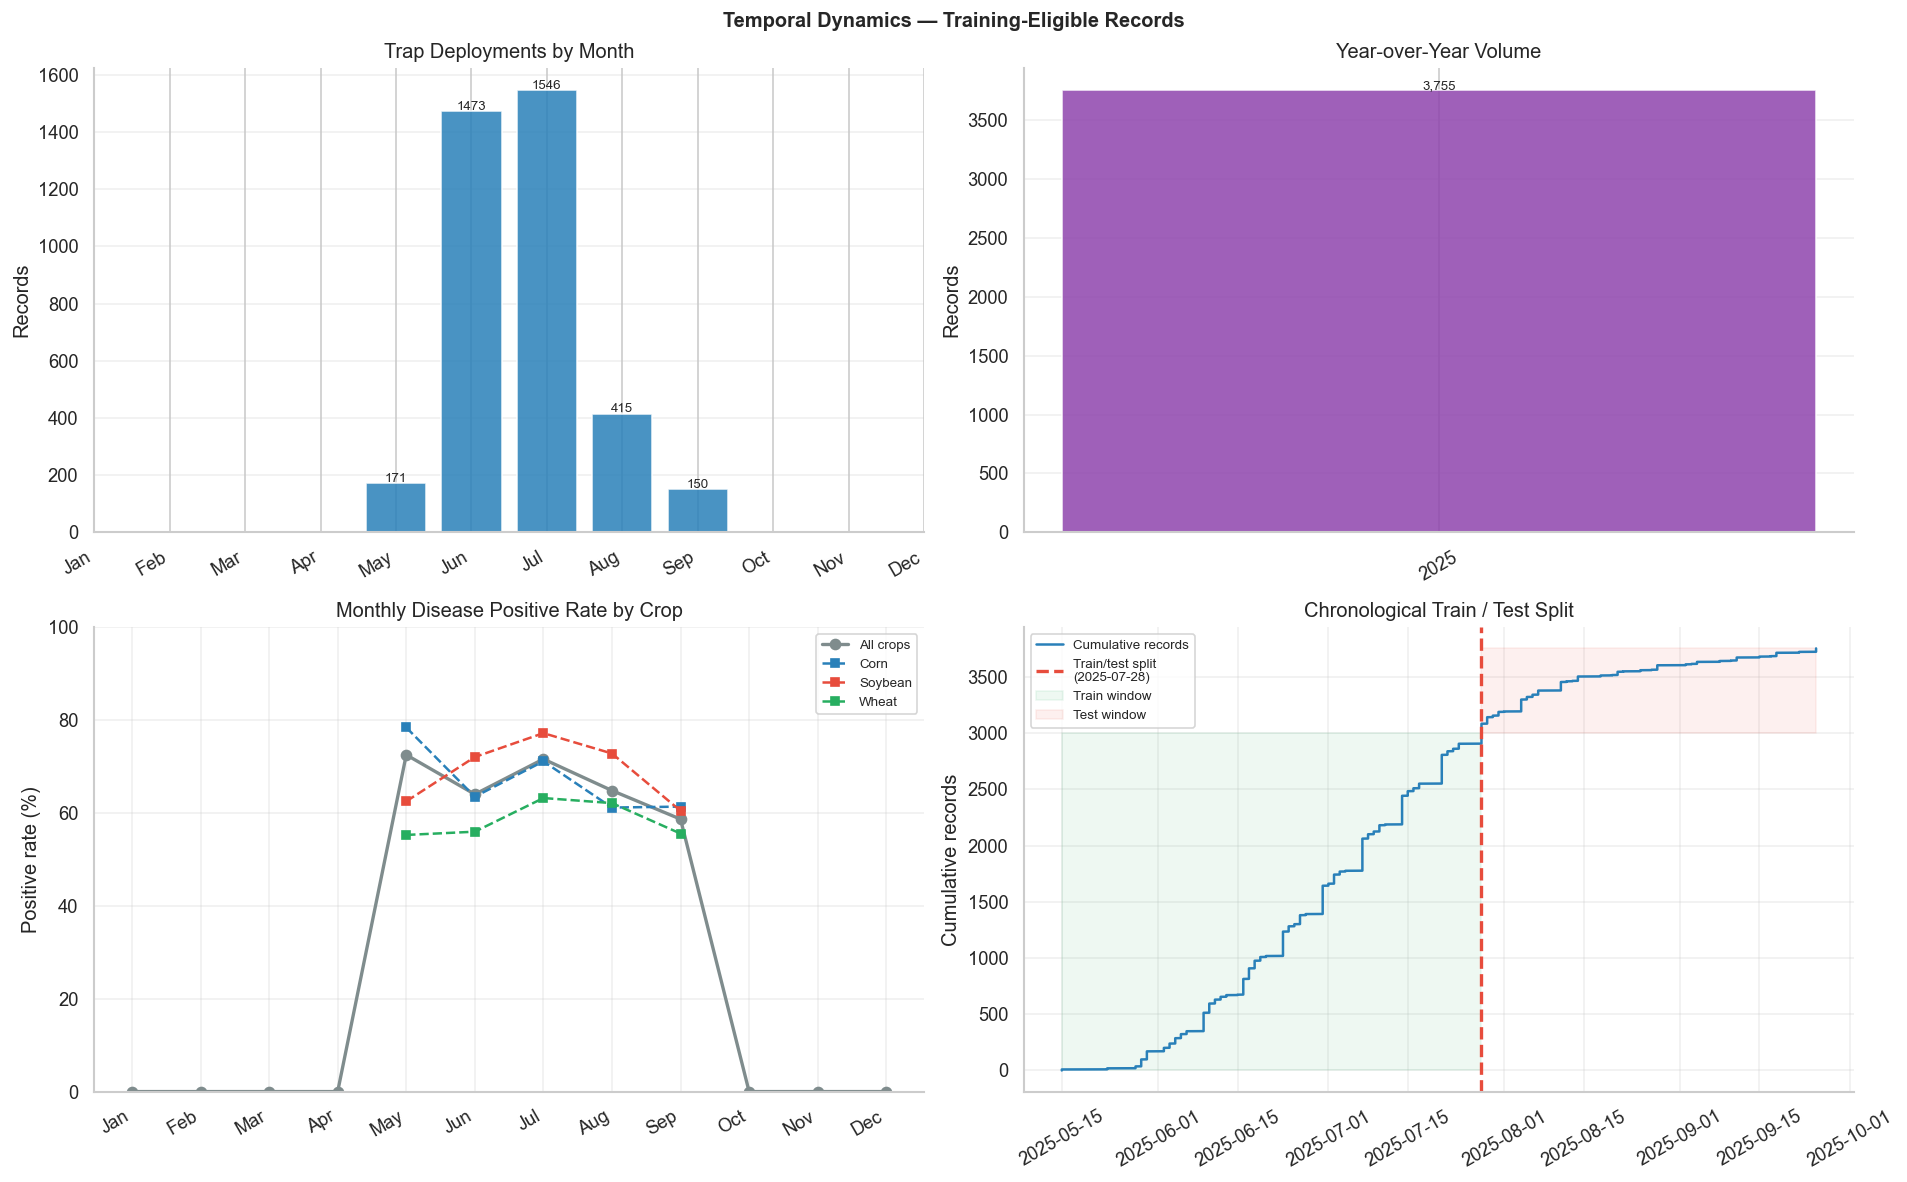

In [27]:
df_t = df_train.copy()

# ── Monthly patterns ──────────────────────────────────────────────────────────
monthly_cnt = df_t["month"].value_counts().sort_index()
monthly_pos = (
    df_t.groupby("month")["disease_present"].mean() * 100
).reindex(range(1, 13), fill_value=0)

# ── Year-over-year volume ─────────────────────────────────────────────────────
yearly_cnt = df_t["year"].value_counts().sort_index().dropna()

# ── Chronological train / test split preview ──────────────────────────────────
test_size    = cfg["data"]["test_size"]
split_n      = int(len(df_t) * (1 - test_size))
split_date   = df_t.sort_values("start_date").iloc[split_n - 1]["start_date"]

MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

print("TEMPORAL DYNAMICS — Training-Eligible Rows")
print("=" * 55)
print(f"  Date range          : {df_t['start_date'].min().date()} – {df_t['start_date'].max().date()}")
print(f"  Train/test split at : {split_date.date()} ({int((1-test_size)*100)}% train / {int(test_size*100)}% test)")
print(f"  Peak deployment month  : {monthly_cnt.idxmax()} ({MONTH_LABELS[monthly_cnt.idxmax()-1]})")
print(f"  Peak positive rate month: {monthly_pos.idxmax()} ({MONTH_LABELS[monthly_pos.idxmax()-1]})")
print()

# Per-crop monthly positive rate
crop_monthly = {}
for crop in CROPS:
    sub = df_t[df_t["crop_type"] == crop]
    crop_monthly[crop] = (
        sub.groupby("month")["disease_present"].mean() * 100
    ).reindex(range(1, 13), fill_value=np.nan)

# ── Visual ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Temporal Dynamics — Training-Eligible Records", fontsize=12, fontweight="bold")

# Monthly deployment volume
axes[0, 0].bar(monthly_cnt.index, monthly_cnt.values,
               color="#2980b9", edgecolor="white", alpha=0.85)
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(MONTH_LABELS, rotation=30, ha="right")
axes[0, 0].set_ylabel("Records")
axes[0, 0].set_title("Trap Deployments by Month")
axes[0, 0].grid(axis="y", alpha=0.3)
for m, v in monthly_cnt.items():
    axes[0, 0].text(m, v + 5, str(v), ha="center", fontsize=8)

# Year-over-year volume
axes[0, 1].bar(yearly_cnt.index.astype(str), yearly_cnt.values,
               color="#8e44ad", edgecolor="white", alpha=0.85)
axes[0, 1].set_ylabel("Records")
axes[0, 1].set_title("Year-over-Year Volume")
axes[0, 1].grid(axis="y", alpha=0.3)
axes[0, 1].tick_params(axis="x", rotation=30)
for i, v in enumerate(yearly_cnt.values):
    axes[0, 1].text(i, v + 5, f"{v:,}", ha="center", fontsize=8)

# Monthly disease positive rate (overall + per crop)
palette = ["#7f8c8d", "#2980b9", "#e74c3c", "#27ae60"]
axes[1, 0].plot(range(1, 13), monthly_pos.values,
                color=palette[0], linewidth=2, marker="o", label="All crops")
for i, crop in enumerate(CROPS):
    axes[1, 0].plot(range(1, 13), crop_monthly[crop].values,
                    color=palette[i + 1], linewidth=1.5, linestyle="--",
                    marker="s", markersize=5, label=crop)
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(MONTH_LABELS, rotation=30, ha="right")
axes[1, 0].set_ylabel("Positive rate (%)")
axes[1, 0].set_ylim(0, 100)
axes[1, 0].set_title("Monthly Disease Positive Rate by Crop")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

# Chronological split preview — cumulative record count
sorted_df = df_t.sort_values("start_date").reset_index(drop=True)
axes[1, 1].plot(sorted_df["start_date"], sorted_df.index,
                color="#2980b9", linewidth=1.5, label="Cumulative records")
axes[1, 1].axvline(split_date, color="#e74c3c", linewidth=2,
                   linestyle="--", label=f"Train/test split\n({split_date.date()})")
axes[1, 1].fill_betweenx([0, split_n], sorted_df["start_date"].iloc[0], split_date,
                          alpha=0.08, color="#27ae60", label="Train window")
axes[1, 1].fill_betweenx([split_n, len(sorted_df)], split_date,
                          sorted_df["start_date"].iloc[-1],
                          alpha=0.08, color="#e74c3c", label="Test window")
axes[1, 1].set_ylabel("Cumulative records")
axes[1, 1].set_title("Chronological Train / Test Split")
axes[1, 1].legend(fontsize=8)
axes[1, 1].tick_params(axis="x", rotation=30)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / "05_temporal_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()

**Note.** Monthly/yearly bar heights reflect how many records fall in each bucket (deployment intensity), not a pure “risk index.” The multi-series plot separates crops because growing seasons and diseases differ.

The cumulative plot marks where the chronological train/test cut sits under `config.yaml` `test_size`. Backtests that respect time order matter here: random K-fold would overstate performance when labels shift by season or year.

## 6. Weather Feature Analysis

Point-biserial correlations between each weather variable and `disease_present`, an inter-feature correlation heatmap to flag collinear inputs, and a temperature quintile analysis to surface nonlinear relationships that justify XGBoost over a linear model.

> **GPS rows only** — weather enrichment requires a confirmed GPS location. Mixing imputed-mean weather from non-GPS rows would corrupt the signal. Only the weather-matched subset is used in this section.

Weather-matched training rows : 3,755
Weather features present      : ['temperature_min_c', 'temperature_max_c', 'temperature_mean_c', 'humidity_max_percent', 'precipitation_mm', 'wind_speed_max_kmh', 'dew_point_min_c']

WEATHER–OUTCOME CORRELATIONS (Pearson r)
--------------------------------------------------
  dew_point_min_c                 +0.1271  ◆ moderate
  temperature_max_c               +0.1172  ◆ moderate
  temperature_mean_c              +0.1112  ◆ moderate
  temperature_min_c               +0.1020  ◆ moderate
  wind_speed_max_kmh              -0.0899  ◆ moderate
  humidity_max_percent            +0.0475    weak
  precipitation_mm                -0.0192    weak

Sign interpretation:
  Positive r → higher value → more disease
  Negative r → higher value → less disease

HIGH COLLINEARITY PAIRS (|r| > 0.80) — review for feature selection:
  temperature_min_c ↔ temperature_max_c  :  r = 0.818
  temperature_min_c ↔ temperature_mean_c  :  r = 0.936
  temperature_min_c ↔ dew_poin

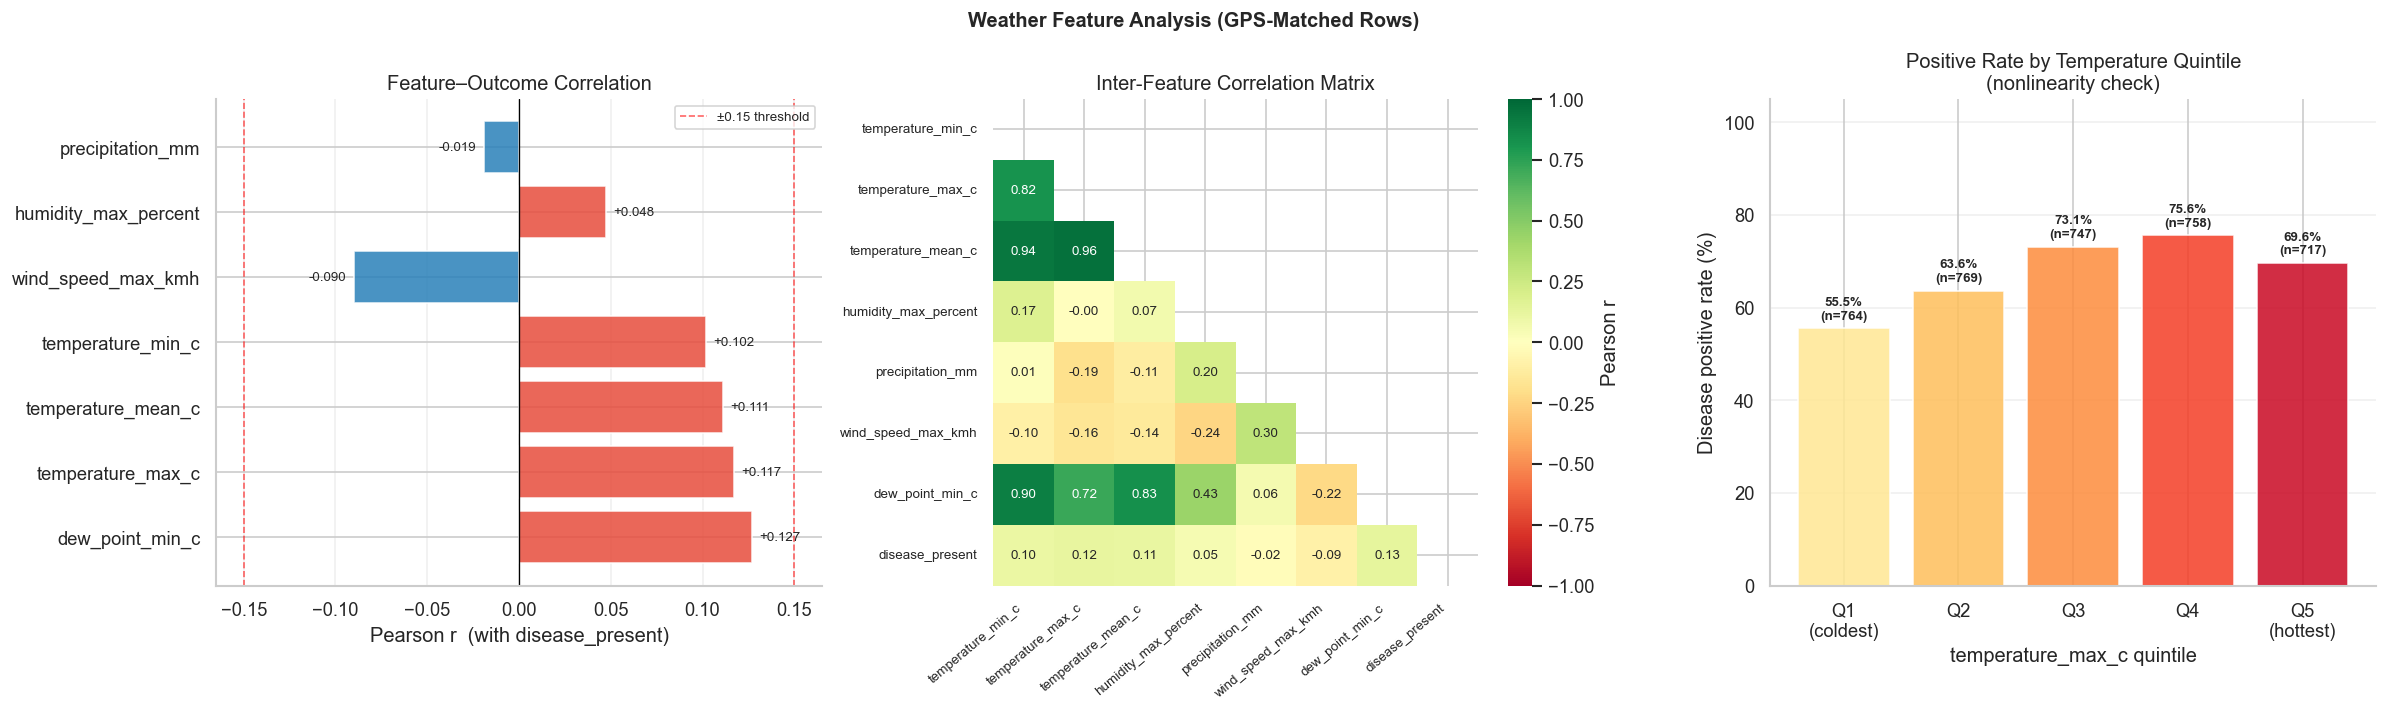

In [28]:
present_wx = [c for c in WEATHER_COLS if c in df_train.columns]
df_wx = df_train[df_train["has_weather"]].copy()

print(f"Weather-matched training rows : {len(df_wx):,}")
print(f"Weather features present      : {present_wx}")
print()

# ── Correlations with outcome ─────────────────────────────────────────────────
corr_outcome = (
    df_wx[present_wx + ["disease_present"]]
    .corr()["disease_present"]
    .drop("disease_present")
    .sort_values(key=abs, ascending=False)
)

print("WEATHER–OUTCOME CORRELATIONS (Pearson r)")
print("-" * 50)
for feat, r in corr_outcome.items():
    if abs(r) > 0.15:   tag = "★ strong"
    elif abs(r) > 0.07: tag = "◆ moderate"
    else:               tag = "  weak"
    print(f"  {feat:<30}  {r:+.4f}  {tag}")

print()
print("Sign interpretation:")
print("  Positive r → higher value → more disease")
print("  Negative r → higher value → less disease")

# ── Inter-feature collinearity ────────────────────────────────────────────────
corr_matrix = df_wx[present_wx + ["disease_present"]].corr()
high_collinear = [
    (a, b, round(corr_matrix.loc[a, b], 3))
    for i, a in enumerate(present_wx)
    for j, b in enumerate(present_wx)
    if j > i and abs(corr_matrix.loc[a, b]) > 0.80
]
if high_collinear:
    print("\nHIGH COLLINEARITY PAIRS (|r| > 0.80) — review for feature selection:")
    for a, b, r in high_collinear:
        print(f"  {a} ↔ {b}  :  r = {r}")
else:
    print("\nNo feature pairs with |r| > 0.80 — collinearity within acceptable range.")

# ── Visual ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Weather Feature Analysis (GPS-Matched Rows)", fontsize=12, fontweight="bold")

# Correlation with outcome
colors_bar = ["#e74c3c" if r > 0 else "#2980b9" for r in corr_outcome.values]
axes[0].barh(corr_outcome.index, corr_outcome.values,
             color=colors_bar, edgecolor="white", alpha=0.85)
axes[0].axvline(0,     color="black", linewidth=0.8)
axes[0].axvline( 0.15, color="red",   linewidth=1, linestyle="--", alpha=0.6, label="±0.15 threshold")
axes[0].axvline(-0.15, color="red",   linewidth=1, linestyle="--", alpha=0.6)
axes[0].set_xlabel("Pearson r  (with disease_present)")
axes[0].set_title("Feature–Outcome Correlation")
axes[0].legend(fontsize=8)
axes[0].grid(axis="x", alpha=0.3)
for bar, val in zip(axes[0].patches, corr_outcome.values):
    axes[0].text(
        val + (0.004 if val >= 0 else -0.004),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.3f}", va="center",
        ha="left" if val >= 0 else "right", fontsize=8,
    )

# Full correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-1, vmax=1, ax=axes[1],
    cbar_kws={"label": "Pearson r"},
    annot_kws={"size": 8},
)
axes[1].set_title("Inter-Feature Correlation Matrix")
plt.setp(axes[1].get_xticklabels(), rotation=40, ha="right", fontsize=8)
plt.setp(axes[1].get_yticklabels(), fontsize=8)

# Temperature quintile analysis — nonlinearity check
if "temperature_max_c" in df_wx.columns:
    df_wx = df_wx.copy()
    df_wx["temp_q"] = pd.qcut(
        df_wx["temperature_max_c"], q=5,
        labels=["Q1\n(coldest)", "Q2", "Q3", "Q4", "Q5\n(hottest)"],
    )
    temp_agg = (
        df_wx.groupby("temp_q", observed=True)["disease_present"]
        .agg(pos_rate="mean", count="count")
        .reset_index()
    )
    temp_agg["pos_rate"] *= 100
    axes[2].bar(
        temp_agg["temp_q"].astype(str), temp_agg["pos_rate"],
        color=sns.color_palette("YlOrRd", 5), edgecolor="white", alpha=0.85,
    )
    for i, (rate, cnt) in enumerate(zip(temp_agg["pos_rate"], temp_agg["count"])):
        axes[2].text(i, rate + 2, f"{rate:.1f}%\n(n={int(cnt)})",
                     ha="center", fontsize=8, fontweight="bold")
    axes[2].set_ylabel("Disease positive rate (%)")
    axes[2].set_xlabel("temperature_max_c quintile")
    axes[2].set_title("Positive Rate by Temperature Quintile\n(nonlinearity check)")
    axes[2].set_ylim(0, 105)
    axes[2].grid(axis="y", alpha=0.3)
else:
    axes[2].text(0.5, 0.5, "temperature_max_c not in dataset",
                 ha="center", va="center", transform=axes[2].transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUTS / "06_weather_features.png", dpi=150, bbox_inches="tight")
plt.show()

**Note.** Pearson *r* versus `disease_present` is a quick linear association screen on rows that already have full weather. It is not causal; pathologists still win on mechanism. Strong tags are candidates to watch for drift; weak tags are not automatically useless (effects can be nonlinear).

The heatmap shows multicollinearity: high |r| between weather derivatives is normal. The quintile plot is a nonlinearity check: if risk jumps mid-range, tree models capture that more easily than a single linear term.

Use these plots with the model’s holdout AUC and calibration, not as a substitute for them.

## 7. Geospatial Coverage

GPS coordinate distribution across training records. Validates that the 15 km weather-station match radius provides adequate coverage and identifies any geographic clusters that may dominate the training set.

GPS-valid training rows : 3,755  of 3,755  (100.0%)
Latitude  range  : 36.430° – 45.148°
Longitude range  : -92.918° – -75.337°

Weather station files   : 100


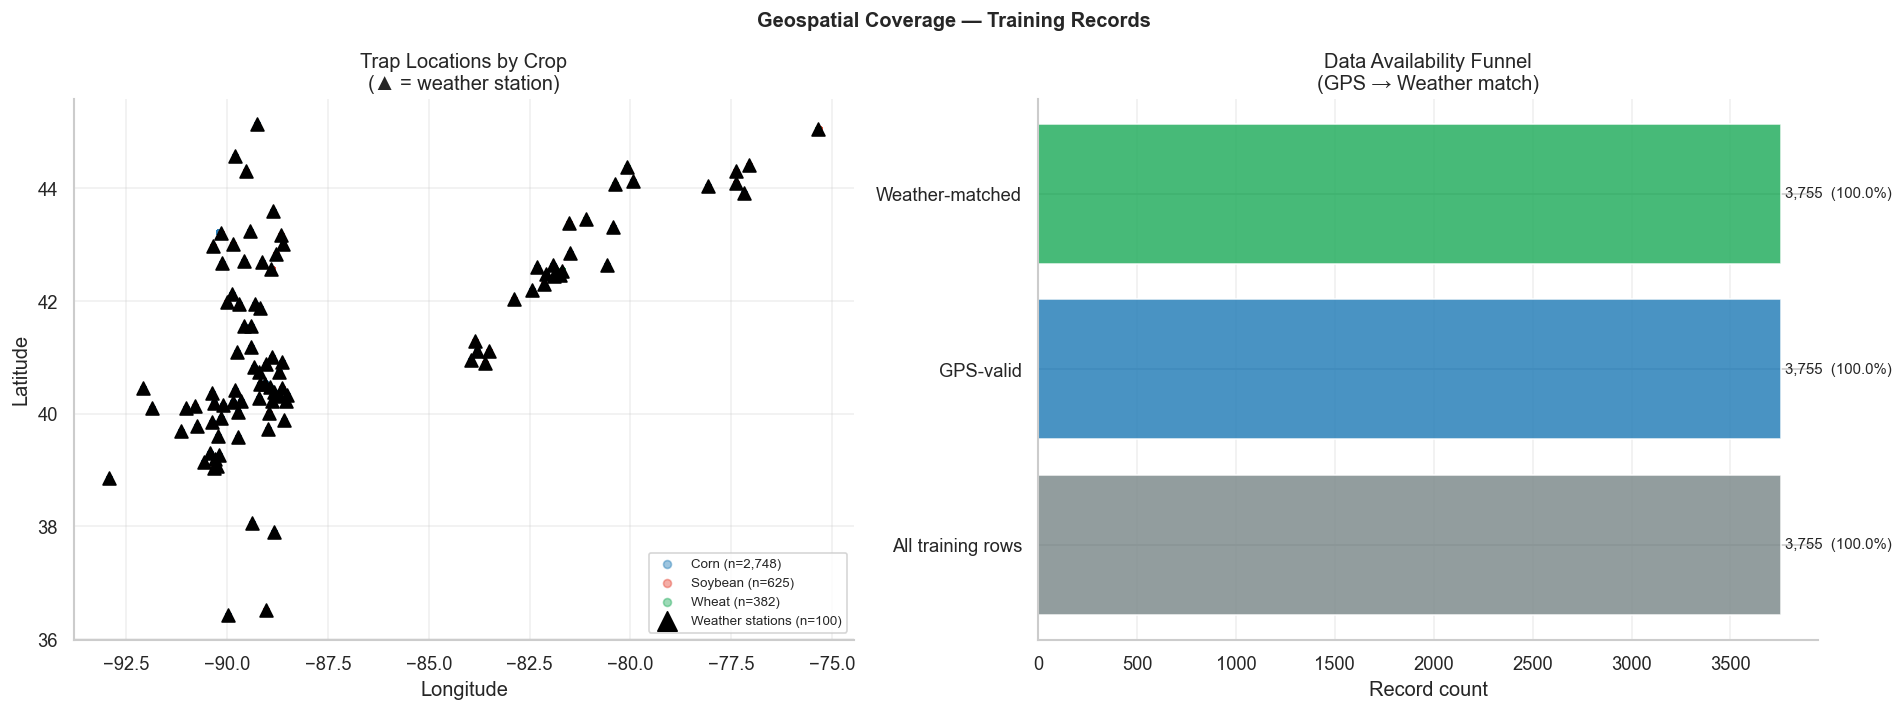

In [29]:
df_geo = df_train[df_train["has_gps"]].copy()

print(f"GPS-valid training rows : {len(df_geo):,}  of {len(df_train):,}  ({len(df_geo)/len(df_train)*100:.1f}%)")
print(f"Latitude  range  : {df_geo['lat'].min():.3f}° – {df_geo['lat'].max():.3f}°")
print(f"Longitude range  : {df_geo['lon'].min():.3f}° – {df_geo['lon'].max():.3f}°")
print()

# Unique weather station locations in data/weather/
import re
WEATHER_DIR = Path(cfg["paths"]["weather_dir"])
weather_stations = []
for f in sorted(WEATHER_DIR.glob("weather_*.csv")):
    m = re.search(r"weather_(.+)_([^_]+)\.csv$", f.name)
    if m:
        try:
            weather_stations.append((float(m.group(1)), float(m.group(2))))
        except ValueError:
            pass
print(f"Weather station files   : {len(weather_stations)}")

# GPS vs weather-matched coverage bar
gps_n    = df_train["has_gps"].sum()
wx_n     = df_train["has_weather"].sum()
total_n  = len(df_train)

# ── Visual ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Geospatial Coverage — Training Records", fontsize=12, fontweight="bold")

# Scatter plot by crop
crop_colors = {"Corn": "#2980b9", "Soybean": "#e74c3c", "Wheat": "#27ae60"}
for crop in CROPS:
    sub = df_geo[df_geo["crop_type"] == crop]
    axes[0].scatter(sub["lon"], sub["lat"],
                    s=10, alpha=0.45,
                    color=crop_colors.get(crop, "#7f8c8d"),
                    label=f"{crop} (n={len(sub):,})")
if weather_stations:
    ws_lats, ws_lons = zip(*weather_stations)
    axes[0].scatter(ws_lons, ws_lats,
                    s=60, marker="^", color="black", zorder=5,
                    label=f"Weather stations (n={len(weather_stations)})")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Trap Locations by Crop\n(▲ = weather station)")
axes[0].legend(fontsize=8, markerscale=1.5)
axes[0].grid(alpha=0.3)

# GPS / weather coverage funnel
categories = ["All training rows", "GPS-valid", "Weather-matched"]
values     = [total_n, int(gps_n), int(wx_n)]
colors_f   = ["#7f8c8d", "#2980b9", "#27ae60"]
bars = axes[1].barh(categories, values, color=colors_f, edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Record count")
axes[1].set_title("Data Availability Funnel\n(GPS → Weather match)")
axes[1].grid(axis="x", alpha=0.3)
for bar, v in zip(bars, values):
    pct = v / total_n * 100
    axes[1].text(v + 20, bar.get_y() + bar.get_height() / 2,
                 f"{v:,}  ({pct:.1f}%)", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS / "07_geospatial_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

**Note.** Trap locations are the geographic basis for joining weather. Station markers are the files available under `data/weather`; they are not necessarily collocated with every trap, but they show the spatial mesh you matched against.

The funnel counts rows that still have GPS and then a complete weather row. Thin coverage in a region means weaker empirical support there: expect wider prediction uncertainty until data fills in, not a bug in the training code.

## 8. Modeling Readiness Report

Per-crop go / no-go assessment against minimum sample thresholds. Surfaces the class imbalance ratio (`scale_pos_weight`) and triangle completeness for each crop, and summarises the deployment plan.

In [30]:
min_samples = cfg["data"]["min_samples_per_crop"]
min_weather = cfg["data"]["min_weather_samples"]

rows = []
for crop in CROPS:
    sub = df_train[df_train["crop_type"] == crop]
    wx  = sub[sub["has_weather"]]
    n_total   = len(sub)
    n_wx      = len(wx)
    n_pos     = int(sub["disease_present"].sum())
    n_neg     = n_total - n_pos
    pos_rate  = round(sub["disease_present"].mean() * 100, 1)
    spw       = round(n_neg / max(n_pos, 1), 2)
    go_total  = n_total >= min_samples
    go_wx     = n_wx    >= min_weather
    rows.append({
        "Crop":              crop,
        "Total rows":        n_total,
        "Weather-matched":   n_wx,
        "Triangle %":        round(n_wx / max(n_total, 1) * 100, 1),
        "Positive rows":     n_pos,
        "Positive rate %":   pos_rate,
        "scale_pos_weight":  spw,
        "Min samples OK":    "✓" if go_total else "✗",
        "Min weather OK":    "✓" if go_wx    else "✗",
        "Status":            "GO" if (go_total and go_wx) else "NO-GO",
    })

readiness = pd.DataFrame(rows).set_index("Crop")
print("MODELING READINESS REPORT")
print("=" * 70)
print(f"  Minimum total samples required  : {min_samples}")
print(f"  Minimum weather samples required: {min_weather}")
print()
print(readiness.to_string())

go_crops   = [r["Crop"] for r in rows if r["Status"] == "GO"]
nogo_crops = [r["Crop"] for r in rows if r["Status"] == "NO-GO"]
print()
print(f"  GO    : {go_crops if go_crops else 'none'}")
print(f"  NO-GO : {nogo_crops if nogo_crops else 'none'}")

# ── Triangle status summary ───────────────────────────────────────────────────
print()
print("DISEASE TRIANGLE STATUS")
print("-" * 50)
print("  [COMPLETE] Weather (Leg 1)  — GPS-matched weather for all GO crops")
print("  [COMPLETE] Spornado (Leg 2) — Raw spore count in every record")
print("  [PENDING]  Hybrid (Leg 3)   — Variety tolerance DB built; awaiting")
print("                                 farmer-reported hybrid variety per field")
print()
print("FEATURE SET (per-crop model)")
print("-" * 50)
print("  Numeric  : 7 weather + 2 location (lat/lon) + 1 deployment duration")
print("             + 3 temporal + 24 rolling weather stats  =  37 features")
print("  Categorical : disease name (one-hot) — 2–5 dummies per crop")
print("  Total    : 39–42 features per crop model")
print()
print("OUTPUTS SAVED TO outputs/")
output_files = [
    "01_dataset_overview.png",
    "02_data_quality.png",
    "03_target_variable.png",
    "04_spore_count.png",
    "04b_disease_breakdown.png",
    "05_temporal_dynamics.png",
    "06_weather_features.png",
    "07_geospatial_coverage.png",
]
for f in output_files:
    p = OUTPUTS / f
    status = "✓" if p.exists() else "✗ (run cell to generate)"
    print(f"  {status}  {f}")

print()
print("MODELS TRAINED  (src/build_crop_models.py — COMPLETE)")
print("-" * 50)
import json
fp = Path("../models/training_metadata.json")
if fp.exists():
    meta = json.loads(fp.read_text(encoding="utf-8"))
    print(f"  Trained at   : {meta.get('trained_at', 'unknown')}")
    print(f"  Model type   : {meta.get('model_type', 'unknown')}")
    print(f"  Crops        : {meta.get('crops_trained', [])}")
    print(f"  Data MD5     : {meta.get('md5_hash', 'unknown')}")
else:
    print("  training_metadata.json not found — run build_crop_models.py first")

print()
print("NEXT STEP → src/predict.py  (run inference on new observations)")

MODELING READINESS REPORT
  Minimum total samples required  : 100
  Minimum weather samples required: 50

         Total rows  Weather-matched  Triangle %  Positive rows  Positive rate %  scale_pos_weight Min samples OK Min weather OK Status
Crop                                                                                                                                   
Corn           2748             2748       100.0           1847             67.2              0.49              ✓              ✓     GO
Soybean         625              625       100.0            459             73.4              0.36              ✓              ✓     GO
Wheat           382              382       100.0            225             58.9              0.70              ✓              ✓     GO

  GO    : ['Corn', 'Soybean', 'Wheat']
  NO-GO : none

DISEASE TRIANGLE STATUS
--------------------------------------------------
  [COMPLETE] Weather (Leg 1)  — GPS-matched weather for all GO crops
  [COMPLETE] S

**Note.** GO / NO-GO is a simple volume check against `min_samples_per_crop` and `min_weather_samples` in config. It does not replace looking at AUC, calibration, or domain sign-off; it only answers whether there is enough labeled, weather-complete history per crop to justify training and stable evaluation.

The triangle lines spell out what is already wired in features (weather + trap/spore-side signal) versus variety inputs that still depend on client-supplied seed data. The PNG list below is what this notebook writes to `outputs/` when cells run successfully.